# Sign2Voice — ASL Landmark Classifier Training

**Pipeline this notebook builds the recognition model for:**

```
Webcam → MediaPipe Hands → Hand Landmarks → Feature Normalization
       → Landmark Classifier → Prediction Stabilization
       → Character / Word Formation → ElevenLabs TTS
```

This notebook trains the **Landmark Classifier** step only. It does **not**
train a YOLO model — the dataset's YOLO bounding boxes are used only to crop
a tight hand ROI before landmark extraction, per the architecture decision
documented in the main project (landmarks generalize far better than raw
pixels to webcam conditions that differ from the training images).

**Key assumptions (see chat for full rationale):**
- MediaPipe classic `solutions.hands` API (static image mode), not the newer Tasks API.
- Normalization: wrist (landmark 0) as origin, scaled by wrist→middle-MCP (landmark 9) distance.
- Class mapping: dataset `data.yaml` names are digit strings `"0"`–`"25"`; the notebook
  asserts this and maps index → letter alphabetically (0→A ... 25→Z), verified against
  sample filenames before training starts.
- Existing train/valid/test split from Roboflow is preserved — **no reshuffling**.

**Run order:** top to bottom. Only `DATASET_ROOT` (and your Roboflow key, entered
securely) need manual input.


## 1. Environment Setup

In [1]:
# Single install step -- avoids the churn of installing opencv-python-headless
# and then immediately uninstalling/reinstalling a different opencv variant.
# mediapipe needs the "contrib" build for full functionality.
!pip install -q roboflow mediapipe opencv-contrib-python-headless \
    scikit-learn tensorflow pandas numpy matplotlib seaborn tqdm pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.1 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import getpass
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
DEVICE = "GPU" if gpus else "CPU"
print("Using device:", DEVICE, f"({len(gpus)} GPU(s) found)" if gpus else "(no GPU found)")


Using device: GPU (1 GPU(s) found)


## 2. Configuration

Edit `DATASET_ROOT` below if you already have the dataset locally. Otherwise
run the download cell, which pulls it from Roboflow (enter your API key
securely — it is never hardcoded or printed).


In [3]:
# ==== Roboflow download (skip this cell if DATASET_ROOT already exists) ====
from roboflow import Roboflow

# Works in Colab (secure secret storage) and falls back to a masked prompt
# everywhere else, so this cell doesn't hard-crash with an ImportError the
# moment the notebook is run outside Colab.
try:
    from google.colab import userdata
    api_key = userdata.get('ROBOFLOW_API_KEY')
except ImportError:
    import getpass
    api_key = getpass.getpass("Enter your Roboflow API key: ")

rf = Roboflow(api_key=api_key)
project = rf.workspace("usfasaadsaad-gmail-com").project("american-language-aqjdk")
version = project.version(1)
dataset = version.download("yolov11")

DATASET_ROOT = dataset.location
print("Dataset downloaded to:", DATASET_ROOT)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to American-Language-1 in yolov11:: 100%|██████████| 16319/16319 [00:04<00:00, 3432.40it/s]

Dataset downloaded to: /content/American-Language-1


In [4]:
# ==== Single config section — change values here only ====

# If you already downloaded the dataset, set this manually and skip the cell above:
# DATASET_ROOT = "/content/american-language-1"

BBOX_MARGIN = 0.10          # extra margin around each YOLO bounding box before cropping
MIN_DETECTION_CONFIDENCE = 0.5   # MediaPipe Hands detection confidence
BATCH_SIZE = 64
NUM_EPOCHS = 60
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 8      # epochs without val-loss improvement before stopping
HIDDEN_DIMS = (128, 64)
DROPOUT = 0.2

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATASET_ROOT = Path(DATASET_ROOT)
SPLITS = ("train", "valid", "test")
print("DATASET_ROOT:", DATASET_ROOT)


DATASET_ROOT: /content/American-Language-1


## 3. Dataset Inspection

### Class ID -> letter mapping (do not trust data.yaml's `names` field blindly)

The Roboflow export's `data.yaml` typically lists class *names* as the digit
strings `"0"`...`"25"` rather than actual letters — those are **not** usable
as final labels. The YOLO label files' numeric class IDs are the source of
truth; we explicitly translate ID -> letter ourselves, alphabetically
(0->A ... 25->Z), and verify the dataset actually has exactly that ID range
before proceeding. If it doesn't, this notebook stops rather than silently
assuming a mapping. Filenames are never used as labels, even though some
happen to encode the letter — only the YOLO annotation's class ID is trusted.


In [5]:
data_yaml_path = DATASET_ROOT / "data.yaml"
assert data_yaml_path.exists(), f"data.yaml not found at {data_yaml_path}"

with open(data_yaml_path) as f:
    data_yaml = yaml.safe_load(f)

raw_names = data_yaml["names"]
print("Raw class names from data.yaml (informational only, NOT used as labels):", raw_names)

# --- Step 1: exactly 26 classes ---
if len(raw_names) != 26:
    raise ValueError(
        f"Expected exactly 26 classes in data.yaml, found {len(raw_names)}. "
        "Stopping rather than guessing a mapping — inspect the dataset export before continuing."
    )

# --- Step 2: scan every label file across all splits and confirm the actual class IDs
#     used are exactly {0, ..., 25} (or a subset of it) -- never anything outside that range ---
observed_class_ids = set()
for split in SPLITS:
    lbl_dir = DATASET_ROOT / split / "labels"
    if not lbl_dir.exists():
        continue
    for label_file in lbl_dir.glob("*.txt"):
        with open(label_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    observed_class_ids.add(int(parts[0]))

print("Observed class IDs across all label files:", sorted(observed_class_ids))

if not observed_class_ids:
    raise ValueError("No class IDs found in any label file — cannot proceed.")

if min(observed_class_ids) < 0 or max(observed_class_ids) > 25:
    raise ValueError(
        f"Found class IDs outside the expected 0-25 range: "
        f"min={min(observed_class_ids)}, max={max(observed_class_ids)}. "
        "Stopping — the alphabetical A-Z mapping assumption does not hold for this export."
    )

if observed_class_ids != set(range(26)):
    missing = sorted(set(range(26)) - observed_class_ids)
    print(f"WARNING: {len(missing)} class IDs never appear in any label file: {missing}. "
          "Those letters will have zero training/val/test samples — continuing, but "
          "flag this explicitly in the graduation report's limitations section.")

# --- Step 3/4: explicit, hardcoded ID -> letter mapping. This is the ONLY mapping used
#     anywhere downstream (y_train/y_val/y_test, class_to_idx, idx_to_class,
#     classification_report, confusion matrix, error analysis, landmark.pt, inference). ---
CLASS_NAMES = [
    "A", "B", "C", "D", "E", "F", "G",
    "H", "I", "J", "K", "L", "M", "N",
    "O", "P", "Q", "R", "S", "T", "U",
    "V", "W", "X", "Y", "Z",
]
assert len(CLASS_NAMES) == 26

class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: name for idx, name in enumerate(CLASS_NAMES)}

print("\nVerified dataset class ID -> letter mapping:")
for idx, name in idx_to_class.items():
    print(f"{idx:2d} -> {name}")


Raw class names from data.yaml (informational only, NOT used as labels): ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '3', '4', '5', '6', '7', '8', '9']
Observed class IDs across all label files: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Verified dataset class ID -> letter mapping:
 0 -> A
 1 -> B
 2 -> C
 3 -> D
 4 -> E
 5 -> F
 6 -> G
 7 -> H
 8 -> I
 9 -> J
10 -> K
11 -> L
12 -> M
13 -> N
14 -> O
15 -> P
16 -> Q
17 -> R
18 -> S
19 -> T
20 -> U
21 -> V
22 -> W
23 -> X
24 -> Y
25 -> Z


In [6]:
split_dirs = {}
summary_rows = []

for split in SPLITS:
    img_dir = DATASET_ROOT / split / "images"
    lbl_dir = DATASET_ROOT / split / "labels"
    if not img_dir.exists():
        print(f"[skip] {split}: no images dir found")
        continue

    images = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")])
    missing_labels = [p for p in images if not (lbl_dir / (p.stem + ".txt")).exists()]

    split_dirs[split] = {"images": img_dir, "labels": lbl_dir, "image_paths": images}
    summary_rows.append({
        "split": split,
        "num_images": len(images),
        "num_missing_labels": len(missing_labels),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

for split, info in split_dirs.items():
    missing = [p for p in info["image_paths"] if not (info["labels"] / (p.stem + ".txt")).exists()]
    if missing:
        print(f"[{split}] {len(missing)} images missing a label file, e.g. {missing[:3]}")


split  num_images  num_missing_labels
train        7137                   0
valid         680                   0
 test         340                   0


In [7]:
def read_yolo_labels(label_path):
    """Return list of (class_id, cx, cy, w, h) tuples, all normalized [0,1]."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id, cx, cy, w, h = parts
            boxes.append((int(class_id), float(cx), float(cy), float(w), float(h)))
    return boxes


def largest_box(boxes):
    """If an image has multiple boxes, keep the largest-area one and log the rest."""
    if not boxes:
        return None, 0
    if len(boxes) == 1:
        return boxes[0], 0
    areas = [w * h for (_, _, _, w, h) in boxes]
    best_idx = int(np.argmax(areas))
    return boxes[best_idx], len(boxes) - 1


# Per-split class balance, using the (single, largest) box's class per image
class_balance = {}
for split, info in split_dirs.items():
    counts = Counter()
    for img_path in info["image_paths"]:
        boxes = read_yolo_labels(info["labels"] / (img_path.stem + ".txt"))
        box, _ = largest_box(boxes)
        if box is not None:
            counts[CLASS_NAMES[box[0]]] += 1
    class_balance[split] = counts

for split, counts in class_balance.items():
    vals = list(counts.values())
    print(f"{split}: {sum(vals)} labeled images | min/class={min(vals) if vals else 0} "
          f"max/class={max(vals) if vals else 0} | classes present={len(counts)}/26")


train: 7137 labeled images | min/class=228 max/class=330 | classes present=26/26
valid: 680 labeled images | min/class=17 max/class=42 | classes present=26/26
test: 340 labeled images | min/class=9 max/class=24 | classes present=26/26


## 4. Bounding Box Visualization\n\nSanity-check the boxes before trusting them for cropping.

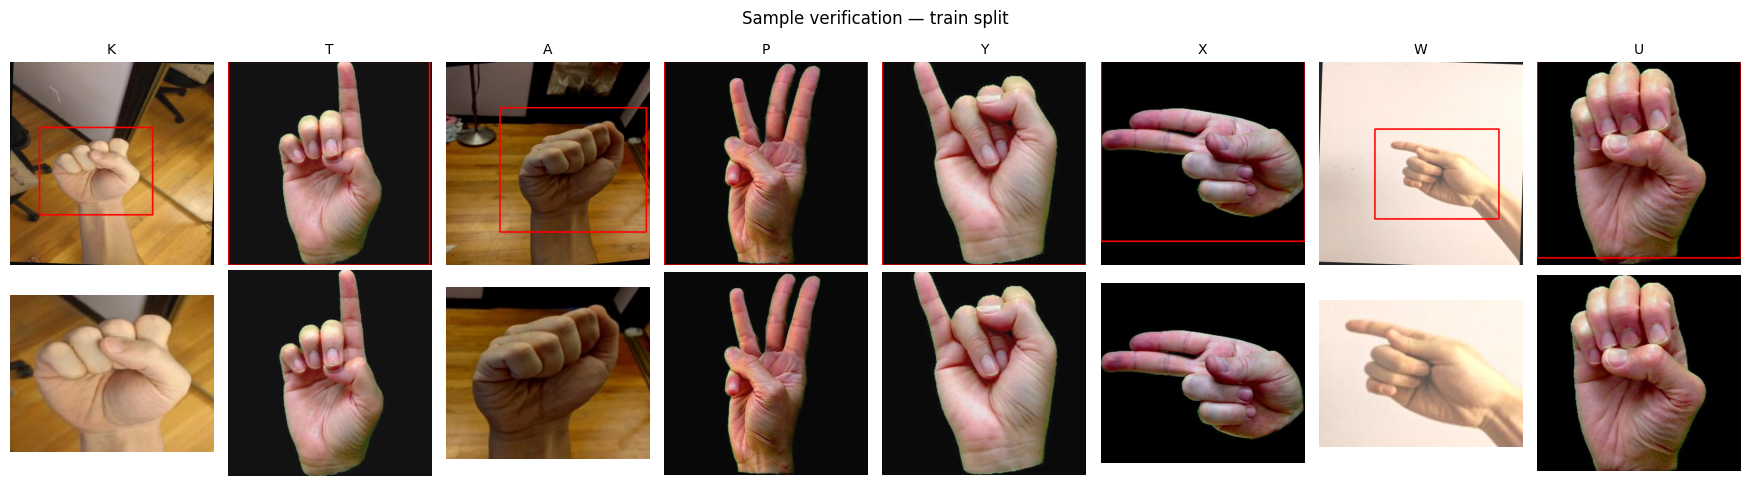

In [8]:
def yolo_to_pixel_bbox(cx, cy, w, h, img_w, img_h, margin=0.0):
    """Convert normalized YOLO center-format box to pixel (x1,y1,x2,y2), with
    an optional fractional margin added on each side, clamped to image bounds."""
    box_w, box_h = w * img_w, h * img_h
    cx_px, cy_px = cx * img_w, cy * img_h

    box_w *= (1 + 2 * margin)
    box_h *= (1 + 2 * margin)

    x1 = int(max(0, cx_px - box_w / 2))
    y1 = int(max(0, cy_px - box_h / 2))
    x2 = int(min(img_w, cx_px + box_w / 2))
    y2 = int(min(img_h, cy_px + box_h / 2))
    return x1, y1, x2, y2


def visualize_samples(split, n=8):
    info = split_dirs[split]
    sample_paths = random.sample(info["image_paths"], min(n, len(info["image_paths"])))

    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5))
    for i, img_path in enumerate(sample_paths):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        boxes = read_yolo_labels(info["labels"] / (img_path.stem + ".txt"))
        box, _ = largest_box(boxes)

        img_with_box = img.copy()
        crop = img
        label = "?"
        if box is not None:
            class_id, cx, cy, bw, bh = box
            x1, y1, x2, y2 = yolo_to_pixel_bbox(cx, cy, bw, bh, w, h, margin=BBOX_MARGIN)
            cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (255, 0, 0), 3)
            crop = img[y1:y2, x1:x2]
            label = CLASS_NAMES[class_id]

        axes[0, i].imshow(img_with_box)
        axes[0, i].set_title(f"{label}", fontsize=10)
        axes[0, i].axis("off")
        axes[1, i].imshow(crop)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("bbox", fontsize=9)
    axes[1, 0].set_ylabel("crop", fontsize=9)
    plt.suptitle(f"Sample verification — {split} split")
    plt.tight_layout()
    plt.show()

visualize_samples("train", n=8)


## 5. Hand ROI Extraction\n\nCrop function is defined above (`yolo_to_pixel_bbox`). This section wraps it into a single crop utility used by the landmark extraction step.

In [9]:
def crop_hand_roi(image, box, margin=BBOX_MARGIN):
    """image: HxWx3 array. box: (class_id, cx, cy, w, h) normalized. Returns cropped array
    clamped to image bounds, or None if the box collapses to an empty region."""
    h, w = image.shape[:2]
    _, cx, cy, bw, bh = box
    x1, y1, x2, y2 = yolo_to_pixel_bbox(cx, cy, bw, bh, w, h, margin=margin)
    if x2 <= x1 or y2 <= y1:
        return None
    return image[y1:y2, x1:x2]


## 6. MediaPipe Landmark Extraction

Every image is processed independently: crop → RGB → MediaPipe Hands
(static image mode, single hand). Failures are logged, not silently dropped,
per the project requirement.


In [10]:
# Download the MediaPipe Tasks HandLandmarker model bundle (one-time).
# This replaces the deprecated mp.solutions.hands legacy API -- solutions.hands
# ships a model internally and needs no download, but it is deprecated and being
# removed from future mediapipe releases, so we pull the equivalent Tasks-API
# model explicitly instead.
import urllib.request

HAND_LANDMARKER_MODEL_PATH = OUTPUT_DIR / "hand_landmarker.task"
HAND_LANDMARKER_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/latest/hand_landmarker.task"
)

if not HAND_LANDMARKER_MODEL_PATH.exists():
    urllib.request.urlretrieve(HAND_LANDMARKER_MODEL_URL, HAND_LANDMARKER_MODEL_PATH)
    print(f"Downloaded hand_landmarker.task -> {HAND_LANDMARKER_MODEL_PATH}")
else:
    print(f"Using cached model at {HAND_LANDMARKER_MODEL_PATH}")


Downloaded hand_landmarker.task -> outputs/hand_landmarker.task


In [11]:
import mediapipe as mp
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python import BaseOptions


def make_hand_landmarker(min_detection_confidence=MIN_DETECTION_CONFIDENCE,
                          running_mode=mp_vision.RunningMode.IMAGE):
    """Builds a HandLandmarker (Tasks API) configured for single-hand, static
    images by default. Use as a context manager: `with make_hand_landmarker() as m:`."""
    options = mp_vision.HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(HAND_LANDMARKER_MODEL_PATH)),
        num_hands=1,
        min_hand_detection_confidence=min_detection_confidence,
        running_mode=running_mode,
    )
    return mp_vision.HandLandmarker.create_from_options(options)


def extract_landmarks_from_crop(hands_model, crop_rgb):
    """Returns a (21, 3) numpy array of (x, y, z) or None if no hand detected."""
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=crop_rgb)
    result = hands_model.detect(mp_image)
    if not result.hand_landmarks:
        return None
    lm = result.hand_landmarks[0]  # single-hand ASL alphabet MVP
    coords = np.array([[p.x, p.y, p.z] for p in lm], dtype=np.float32)
    return coords


def process_split(split, hands_model):
    """Every image produces exactly one log entry, whether it succeeds or is
    skipped. Nothing is silently discarded -- 'skipped' rows explain why."""
    info = split_dirs[split]
    landmarks_list, labels_list, image_paths_used = [], [], []
    log_rows = []

    for img_path in tqdm(info["image_paths"], desc=f"Extracting landmarks [{split}]"):
        row = {"split": split, "image": str(img_path), "status": "skipped",
               "reason": None, "num_boxes": 0}

        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            row["reason"] = "unreadable_image"
            log_rows.append(row)
            continue

        boxes = read_yolo_labels(info["labels"] / (img_path.stem + ".txt"))
        row["num_boxes"] = len(boxes)
        box, n_extra = largest_box(boxes)

        if box is None:
            row["reason"] = "no_bbox_label"
            log_rows.append(row)
            continue

        crop = crop_hand_roi(img_bgr, box)
        if crop is None or crop.size == 0:
            row["reason"] = "empty_crop"
            log_rows.append(row)
            continue

        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        landmarks = extract_landmarks_from_crop(hands_model, crop_rgb)
        if landmarks is None:
            row["reason"] = "no_hand_detected"
            log_rows.append(row)
            continue

        # Success -- but still explicitly log if multiple boxes were present,
        # since the largest-box choice is a modeling decision worth auditing.
        landmarks_list.append(landmarks)
        labels_list.append(CLASS_NAMES[box[0]])
        image_paths_used.append(str(img_path))

        row["status"] = "success"
        row["reason"] = "multiple_boxes_kept_largest" if n_extra > 0 else "single_box"
        log_rows.append(row)

    n_success = len(landmarks_list)
    n_total = len(info["image_paths"])
    n_multibox = sum(1 for r in log_rows if r["reason"] == "multiple_boxes_kept_largest")
    print(f"[{split}] {n_success}/{n_total} succeeded "
          f"({100 * n_success / max(1, n_total):.1f}%), "
          f"{n_multibox} images had multiple boxes (largest kept, logged)")

    return landmarks_list, labels_list, image_paths_used, log_rows


In [12]:
raw_landmarks = {}
raw_labels = {}
raw_paths = {}
all_log_rows = []

with make_hand_landmarker(running_mode=mp_vision.RunningMode.IMAGE) as hands_model:
    for split in split_dirs:
        lms, lbls, paths, log_rows = process_split(split, hands_model)
        raw_landmarks[split] = lms
        raw_labels[split] = lbls
        raw_paths[split] = paths
        all_log_rows.extend(log_rows)

extraction_log_df = pd.DataFrame(all_log_rows)
extraction_log_path = OUTPUT_DIR / "landmark_extraction_log.csv"
extraction_log_df.to_csv(extraction_log_path, index=False)
print(f"Saved full per-image extraction log ({len(extraction_log_df)} rows) to {extraction_log_path}")

# Filtered view: only skipped images -- kept under the originally requested filename
failures_df = extraction_log_df[extraction_log_df["status"] == "skipped"].drop(columns=["status"])
failures_path = OUTPUT_DIR / "landmark_extraction_failures.csv"
failures_df.to_csv(failures_path, index=False)
print(f"Saved {len(failures_df)} skipped/failure records to {failures_path}")
if len(failures_df):
    print(failures_df["reason"].value_counts())

n_multibox = (extraction_log_df["reason"] == "multiple_boxes_kept_largest").sum()
print(f"\n{n_multibox} successfully-extracted images had multiple boxes (largest kept) -- see extraction log.")


Extracting landmarks [train]:   0%|          | 0/7137 [00:00<?, ?it/s]

[train] 4222/7137 succeeded (59.2%), 0 images had multiple boxes (largest kept, logged)


Extracting landmarks [valid]:   0%|          | 0/680 [00:00<?, ?it/s]

[valid] 408/680 succeeded (60.0%), 0 images had multiple boxes (largest kept, logged)


Extracting landmarks [test]:   0%|          | 0/340 [00:00<?, ?it/s]

[test] 225/340 succeeded (66.2%), 0 images had multiple boxes (largest kept, logged)
Saved full per-image extraction log (8157 rows) to outputs/landmark_extraction_log.csv
Saved 3302 skipped/failure records to outputs/landmark_extraction_failures.csv
reason
no_hand_detected    3302
Name: count, dtype: int64

0 successfully-extracted images had multiple boxes (largest kept) -- see extraction log.


In [13]:
# Defined here (rather than only in Section 7) because the augmentation step
# below needs to know which landmark is the wrist to rotate/scale around.
# Section 7 reuses these same names -- not redefined there.
WRIST_IDX = 0
MIDDLE_MCP_IDX = 9  # stable reference distance for scale normalization


## 6b. Landmark Augmentation (train split only)

The static training images don't cover the pose/scale/rotation variability a
live webcam feed will produce. Augmenting **in landmark space** (small
in-plane rotation, scale jitter, coordinate noise around the wrist) is cheap
and geometrically meaningful — unlike pixel-space augmentation, it doesn't
require re-running MediaPipe. Applied to `train` only, after extraction and
before `extract_features()`, so validation/test stay an unmodified read of
the original images and scores remain comparable to a non-augmented run.


In [14]:
AUGMENTATIONS_PER_SAMPLE = 2   # extra augmented copies generated per training image
AUG_MAX_ROTATION_DEG = 15      # small in-plane rotation -- ASL handshapes are somewhat
                                # rotation-sensitive (e.g. M/N vs upside-down variants),
                                # so this stays modest rather than a full +/-180
AUG_SCALE_RANGE = (0.90, 1.10) # hand-to-camera distance varies on a live feed
AUG_NOISE_STD = 0.01           # small jitter approximating MediaPipe detection noise

aug_rng = np.random.default_rng(SEED)


def augment_landmarks(landmarks: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """landmarks: (21, 3) raw MediaPipe (x, y, z), crop-relative.
    Rotates in-plane around the wrist, applies isotropic scale jitter, and adds
    small gaussian coordinate noise. Returns a new (21, 3) array; input is untouched.
    """
    wrist = landmarks[WRIST_IDX]
    centered = landmarks - wrist

    theta = np.deg2rad(rng.uniform(-AUG_MAX_ROTATION_DEG, AUG_MAX_ROTATION_DEG))
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    rot = np.array([[cos_t, -sin_t, 0.0],
                     [sin_t,  cos_t, 0.0],
                     [0.0,    0.0,   1.0]], dtype=np.float32)
    rotated = centered @ rot.T

    scale = rng.uniform(*AUG_SCALE_RANGE)
    scaled = rotated * scale

    noisy = scaled + rng.normal(0, AUG_NOISE_STD, size=scaled.shape).astype(np.float32)
    return (noisy + wrist).astype(np.float32)


n_before = len(raw_landmarks["train"])
aug_landmarks, aug_labels = [], []
for lm, label in zip(raw_landmarks["train"], raw_labels["train"]):
    for _ in range(AUGMENTATIONS_PER_SAMPLE):
        aug_landmarks.append(augment_landmarks(lm, aug_rng))
        aug_labels.append(label)

raw_landmarks["train"] = raw_landmarks["train"] + aug_landmarks
raw_labels["train"] = raw_labels["train"] + aug_labels
# raw_paths["train"] is intentionally NOT extended -- augmented samples have no
# corresponding source image, and raw_paths is only used for test-split error
# analysis, which never touches augmented data.

n_train_total = len(raw_landmarks["train"])
print(f"Train split augmented: {n_before} originals -> "
      f"+{len(aug_landmarks)} augmented copies "
      f"({AUGMENTATIONS_PER_SAMPLE}x) -> {n_train_total} total")


Train split augmented: 4222 originals -> +8444 augmented copies (2x) -> 12666 total


## 7. Landmark Feature Engineering

`extract_features()` is the single source of truth for normalization —
this exact function must be reused by inference code later (`classifier.py`),
not reimplemented.


In [15]:
# WRIST_IDX / MIDDLE_MCP_IDX already defined in Section 6b (needed there for augmentation)


def extract_features(landmarks: np.ndarray) -> np.ndarray:
    """landmarks: (21, 3) array of raw MediaPipe (x, y, z).
    Returns a flattened (63,) normalized feature vector.

    Normalization:
      1. Translate so the wrist (landmark 0) is the origin.
      2. Scale by the wrist -> middle-finger-MCP (landmark 9) distance, a stable
         reference that doesn't collapse for any letter shape (unlike, e.g.,
         fingertip spread, which varies a lot between letters by design).
      3. Flatten 21x3 -> 63.
    """
    origin = landmarks[WRIST_IDX]
    centered = landmarks - origin

    scale_ref = np.linalg.norm(centered[MIDDLE_MCP_IDX])
    scale_ref = max(scale_ref, 1e-6)  # avoid divide-by-zero on degenerate detections

    normalized = centered / scale_ref
    return normalized.flatten().astype(np.float32)


NORMALIZATION_INFO = {
    "origin_landmark_idx": WRIST_IDX,
    "scale_reference_landmark_idx": MIDDLE_MCP_IDX,
    "method": "translate_to_origin_then_scale_by_reference_distance",
}


In [16]:
features = {}
for split in raw_landmarks:
    features[split] = np.stack([extract_features(lm) for lm in raw_landmarks[split]]) \
        if raw_landmarks[split] else np.zeros((0, 63), dtype=np.float32)
    print(f"{split}: features shape = {features[split].shape}")


train: features shape = (12666, 63)
valid: features shape = (408, 63)
test: features shape = (225, 63)


## 8. Build Feature Dataset

Preserves the original train/valid/test split — no reshuffling, so there is
no risk of leaking a training image (or its augmented variant) into
validation or test.


In [17]:
# class_to_idx / idx_to_class were already built and verified in the dataset-inspection
# cell above -- reused here as-is, never rebuilt, so there is exactly one mapping used
# consistently through labels, training, evaluation, and the saved checkpoint.

def labels_to_idx(label_list):
    return np.array([class_to_idx[l] for l in label_list], dtype=np.int64)

X_train_raw, y_train = features["train"], labels_to_idx(raw_labels["train"])
X_val_raw, y_val = features["valid"], labels_to_idx(raw_labels["valid"])
X_test_raw, y_test = features["test"], labels_to_idx(raw_labels["test"])

test_paths = raw_paths["test"]  # kept for error analysis later

for name, X, y in [("train", X_train_raw, y_train), ("val", X_val_raw, y_val), ("test", X_test_raw, y_test)]:
    dist = Counter(y.tolist())
    print(f"{name}: X={X.shape}, y={y.shape}, classes present={len(dist)}/26, "
          f"min/class={min(dist.values()) if dist else 0}, max/class={max(dist.values()) if dist else 0}")


train: X=(12666, 63), y=(12666,), classes present=26/26, min/class=153, max/class=807
val: X=(408, 63), y=(408,), classes present=26/26, min/class=3, max/class=31
test: X=(225, 63), y=(225,), classes present=26/26, min/class=3, max/class=19


### Feature scaling — StandardScaler fit on train only

`extract_features()` above only does the *geometric* normalization (wrist
origin + scale by wrist->middle-MCP distance). On top of that, we fit a
`StandardScaler` — but **only on `X_train`**, then apply that exact fitted
scaler to validation, test, and (at inference time) live predictions. Fitting
on val/test would leak their distribution into preprocessing, which is a
subtle but real form of data leakage. The fitted scaler's parameters are
stored inside `landmark.pt` so deployment code never needs to refit it.


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

SCALER_INFO = {
    "mean": scaler.mean_.astype(np.float32),
    "scale": scaler.scale_.astype(np.float32),
}
print("StandardScaler fit on X_train only. mean/scale shapes:",
      SCALER_INFO["mean"].shape, SCALER_INFO["scale"].shape)


StandardScaler fit on X_train only. mean/scale shapes: (63,) (63,)


In [19]:
np.savez(
    OUTPUT_DIR / "landmarks_dataset.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)

with open(OUTPUT_DIR / "class_mapping.json", "w") as f:
    json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, f, indent=2)

# Saved so the error-analysis / demo cells further down are reproducible without
# re-running the (slow) MediaPipe extraction step from scratch.
with open(OUTPUT_DIR / "test_paths.json", "w") as f:
    json.dump(test_paths, f, indent=2)

print("Saved landmarks_dataset.npz, class_mapping.json, and test_paths.json to", OUTPUT_DIR)


Saved landmarks_dataset.npz, class_mapping.json, and test_paths.json to outputs


## 9. TensorFlow / Keras Model — small MLP


In [20]:
def build_landmark_mlp(input_dim=63, hidden_dims=(128, 64), num_classes=26, dropout=0.2):
    """Input: 63 normalized landmark features -> 26-class logits.
    Deliberately small: this is a geometric-feature classifier, not an image
    model, so it doesn't need convolutional capacity or depth."""
    inputs = keras.Input(shape=(input_dim,), name="landmark_features")
    x = inputs
    for h in hidden_dims:
        x = layers.Dense(h, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, name="logits")(x)  # linear -- logits, not softmax
    return keras.Model(inputs=inputs, outputs=outputs, name="LandmarkMLP")


MODEL_CONFIG = {
    "input_dim": 63,
    "hidden_dims": list(HIDDEN_DIMS),
    "num_classes": 26,
    "dropout": DROPOUT,
}

model = build_landmark_mlp(**MODEL_CONFIG)
model.summary()


Model: "LandmarkMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ landmark_features (InputLayer)  │ (None, 63)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,138 (70.85 KB)

 Trainable params: 18,138 (70.85 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(buffer_size=len(X_train), seed=SEED) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


### Class weights — inverse-frequency, computed on `y_train` only

Section 3 explicitly flags that some letters may be under-represented (or
even entirely missing) in the dataset. Rather than only *reporting* that
imbalance, weight the loss so rare classes aren't drowned out by common ones.
Weights are derived purely from the training split's label counts — using
val/test counts here would be the same kind of leakage the `StandardScaler`
note above warns about.


In [22]:
train_class_counts = np.bincount(y_train, minlength=26).astype(np.float32)
# Classes with zero training samples get weight 0 (they can't be learned or
# meaningfully penalized either way) instead of a divide-by-zero.
class_weights = np.where(
    train_class_counts > 0,
    train_class_counts.sum() / np.maximum(train_class_counts, 1) / 26,
    0.0,
).astype(np.float32)

# Keras' model.fit(class_weight=...) expects a {class_idx: weight} dict, not a tensor.
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}

print("Per-class training counts:", dict(zip(CLASS_NAMES, train_class_counts.astype(int).tolist())))
print("Per-class loss weights:   ", dict(zip(CLASS_NAMES, np.round(class_weights, 3).tolist())))


Per-class training counts: {'A': 465, 'B': 636, 'C': 708, 'D': 807, 'E': 153, 'F': 282, 'G': 288, 'H': 531, 'I': 243, 'J': 552, 'K': 393, 'L': 240, 'M': 393, 'N': 648, 'O': 624, 'P': 558, 'Q': 555, 'R': 405, 'S': 522, 'T': 633, 'U': 279, 'V': 684, 'W': 597, 'X': 549, 'Y': 558, 'Z': 363}
Per-class loss weights:    {'A': 1.0479999780654907, 'B': 0.765999972820282, 'C': 0.6880000233650208, 'D': 0.6039999723434448, 'E': 3.184000015258789, 'F': 1.7269999980926514, 'G': 1.6920000314712524, 'H': 0.9169999957084656, 'I': 2.005000114440918, 'J': 0.8830000162124634, 'K': 1.2400000095367432, 'L': 2.0299999713897705, 'M': 1.2400000095367432, 'N': 0.7519999742507935, 'O': 0.781000018119812, 'P': 0.8730000257492065, 'Q': 0.878000020980835, 'R': 1.2029999494552612, 'S': 0.9330000281333923, 'T': 0.7699999809265137, 'U': 1.746000051498413, 'V': 0.7120000123977661, 'W': 0.8159999847412109, 'X': 0.8870000243186951, 'Y': 0.8730000257492065, 'Z': 1.3420000076293945}


## 10. Training (with early stopping on validation loss)

In [23]:
# class_weight=class_weight_dict -- computed above from y_train counts only
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# Halves LR after 3 epochs without val_loss improvement, so training can keep
# making progress in between full early-stopping resets (EARLY_STOPPING_PATIENCE=8).
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", mode="min", factor=0.5, patience=3, verbose=1,
)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True, verbose=1,
)

lr_history = []
class LRLogger(keras.callbacks.Callback):
    """Keras doesn't log the live learning rate into `history` by default --
    this records it each epoch so the training-curves plot below can show it."""
    def on_epoch_end(self, epoch, logs=None):
        lr_history.append(float(self.model.optimizer.learning_rate.numpy()))

history_obj = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr, early_stop, LRLogger()],
    verbose=2,
)

history = {
    "train_loss": history_obj.history["loss"],
    "val_loss": history_obj.history["val_loss"],
    "train_acc": history_obj.history["accuracy"],
    "val_acc": history_obj.history["val_accuracy"],
    "lr": lr_history,
}

# EarlyStopping(restore_best_weights=True) already reloaded the best-val-loss
# weights into `model` -- report the metrics for that same epoch.
best_epoch = int(np.argmin(history["val_loss"]))
best_val_loss = float(history["val_loss"][best_epoch])
best_val_accuracy = float(history["val_acc"][best_epoch])
print(f"\nLoaded best checkpoint (selected by lowest val_loss). "
      f"best_val_loss={best_val_loss:.4f}, val_accuracy_at_that_epoch={best_val_accuracy:.4f}")


Epoch 1/60
198/198 - 6s - 32ms/step - accuracy: 0.3632 - loss: 2.2597 - val_accuracy: 0.7770 - val_loss: 1.0222 - learning_rate: 0.0010
Epoch 2/60
198/198 - 1s - 3ms/step - accuracy: 0.6520 - loss: 1.1834 - val_accuracy: 0.8382 - val_loss: 0.5931 - learning_rate: 0.0010
Epoch 3/60
198/198 - 1s - 3ms/step - accuracy: 0.7458 - loss: 0.8618 - val_accuracy: 0.8554 - val_loss: 0.4439 - learning_rate: 0.0010
Epoch 4/60
198/198 - 1s - 3ms/step - accuracy: 0.7874 - loss: 0.7149 - val_accuracy: 0.8824 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 5/60
198/198 - 1s - 3ms/step - accuracy: 0.8141 - loss: 0.6240 - val_accuracy: 0.9142 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 6/60
198/198 - 1s - 4ms/step - accuracy: 0.8344 - loss: 0.5661 - val_accuracy: 0.9216 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 7/60
198/198 - 1s - 6ms/step - accuracy: 0.8468 - loss: 0.5081 - val_accuracy: 0.9240 - val_loss: 0.2814 - learning_rate: 0.0010
Epoch 8/60
198/198 - 1s - 3ms/step - accuracy: 0.8634 

## 11. Training Curves

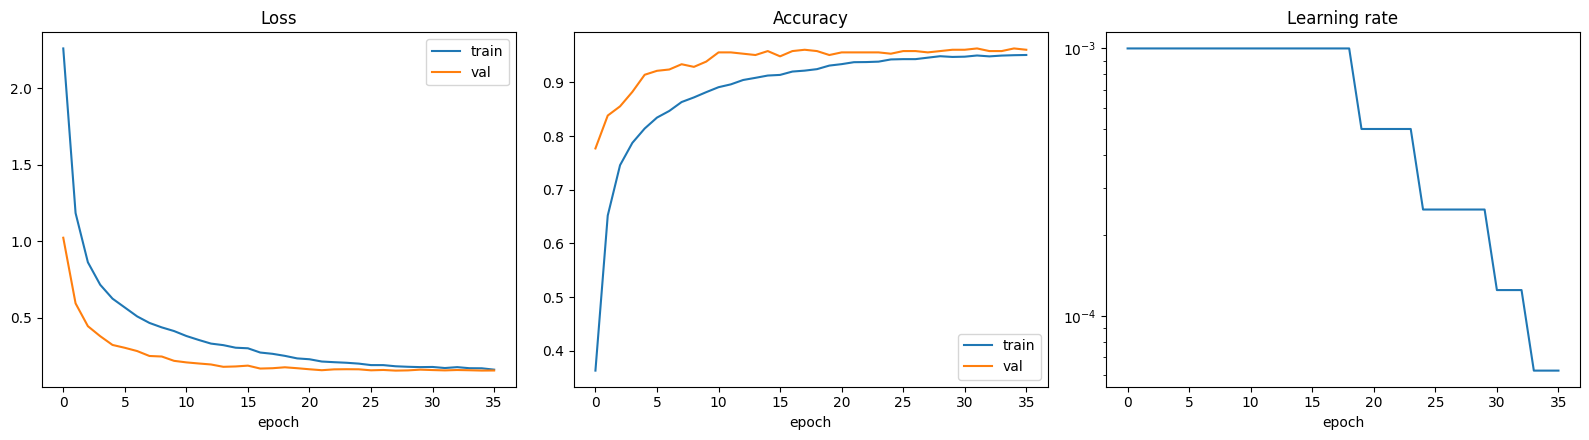

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(history["lr"])
axes[2].set_title("Learning rate")
axes[2].set_xlabel("epoch")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()


## 12. Evaluation — test set only

Evaluated exactly once, on the held-out test split, using the best
checkpoint selected by validation loss.


In [25]:
logits = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
probs = tf.nn.softmax(logits, axis=1).numpy()

all_preds = probs.argmax(axis=1).tolist()
all_conf = probs.max(axis=1).tolist()
all_true = y_test.tolist()

test_accuracy = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="macro", zero_division=0)

print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Macro precision: {precision:.4f}")
print(f"Macro recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}")
print()
print(classification_report(
    all_true, all_preds,
    labels=list(range(26)),  # explicit, full label set -- without this, classification_report
                              # infers labels from the data actually seen and crashes with a
                              # target_names-length mismatch the moment any class (e.g. one flagged
                              # missing back in Section 3) doesn't appear in this particular test run
    target_names=[idx_to_class[i] for i in range(26)],
    zero_division=0,
))


Test accuracy:  0.9289
Macro precision: 0.9140
Macro recall:    0.9122
Macro F1:        0.9063

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         6
           B       1.00      1.00      1.00        11
           C       1.00      1.00      1.00        12
           D       1.00      1.00      1.00        13
           E       1.00      0.83      0.91         6
           F       1.00      1.00      1.00         5
           G       0.67      0.67      0.67         3
           H       1.00      1.00      1.00         6
           I       0.88      0.88      0.88         8
           J       1.00      1.00      1.00        12
           K       0.62      1.00      0.77         5
           L       0.50      0.67      0.57         3
           M       1.00      0.67      0.80         6
           N       1.00      1.00      1.00         8
           O       0.78      1.00      0.88         7
           P       1.00      0.85      

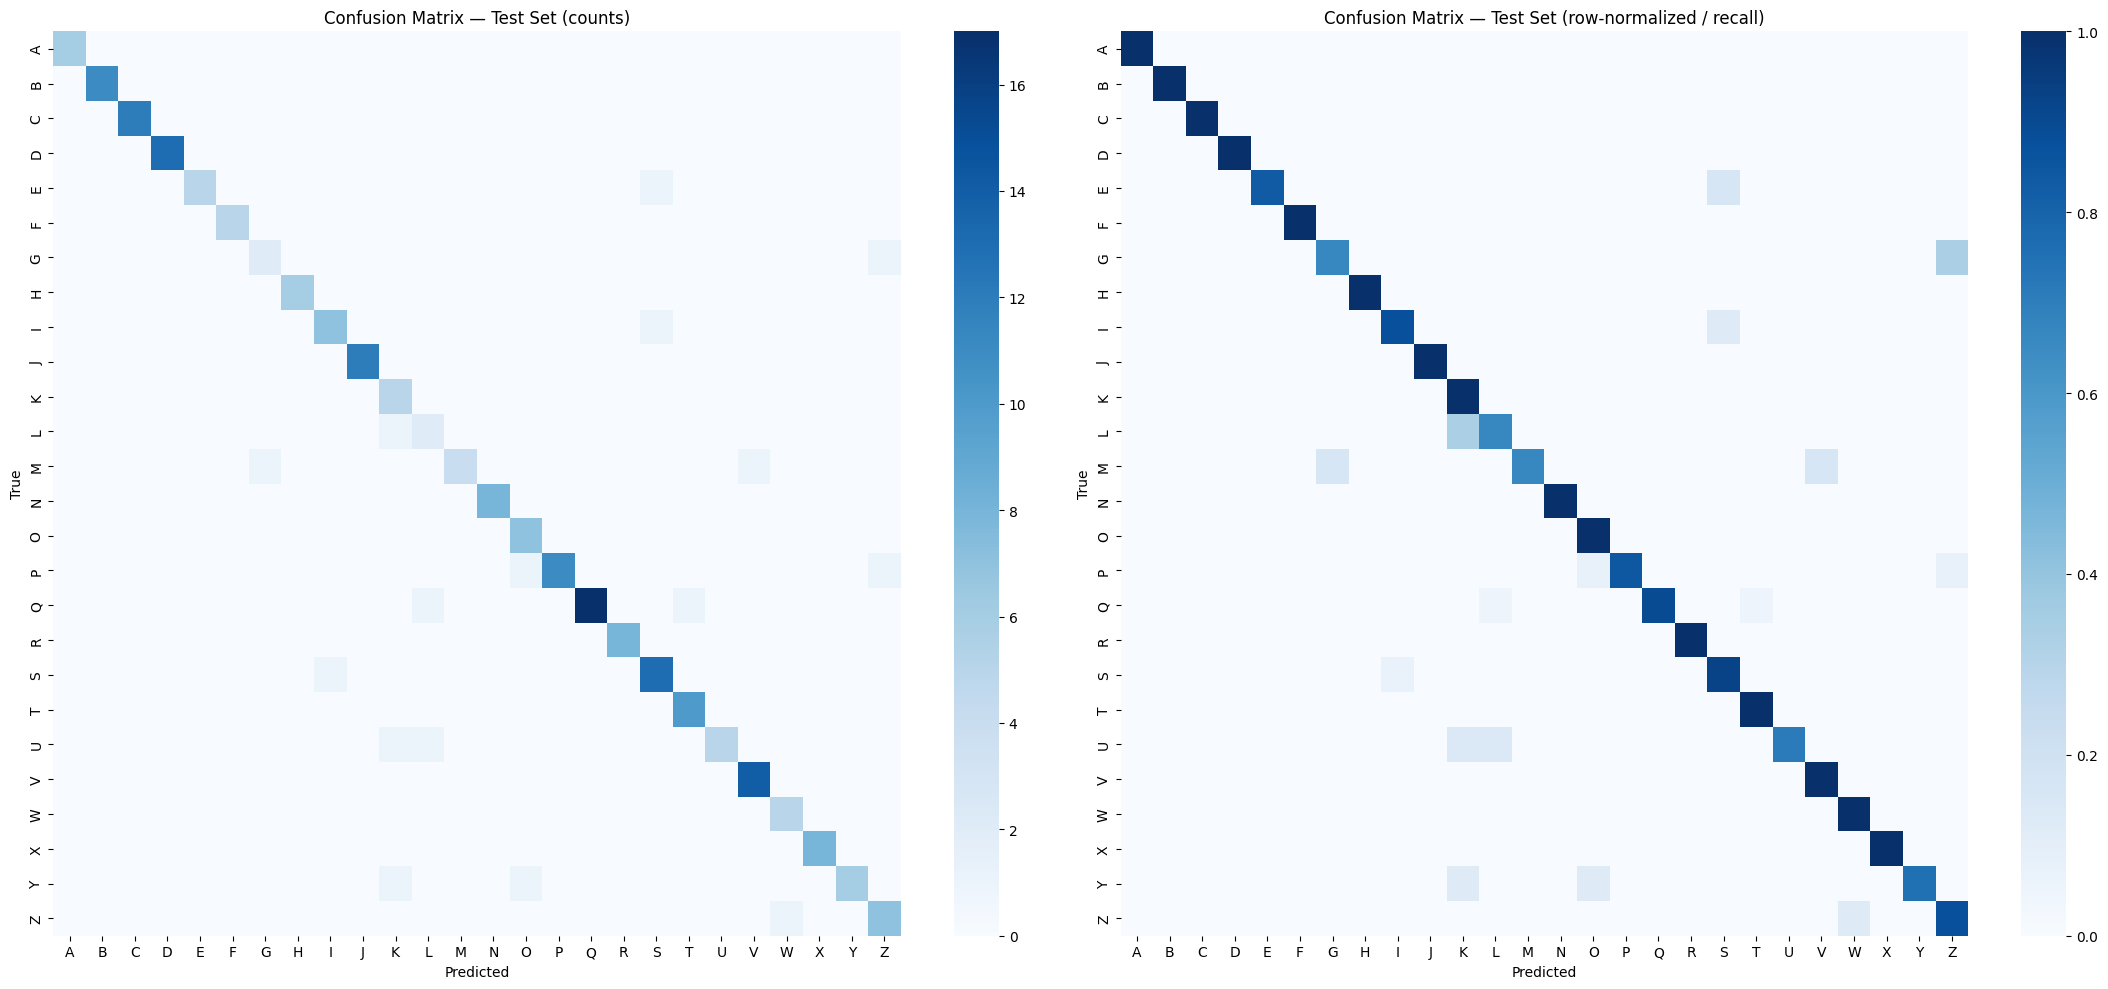

In [26]:
cm = confusion_matrix(all_true, all_preds, labels=list(range(26)))
# Row-normalized view -- with class imbalance, raw counts make common letters
# look "more confused" just because there are more of them. Per-row percentages
# (each row = recall breakdown for that true class) are the more honest read.
with np.errstate(invalid="ignore", divide="ignore"):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # rows with 0 true samples (missing classes) -> 0s, not NaN

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix — Test Set (counts)")

sns.heatmap(cm_norm, annot=False, cmap="Blues", vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix — Test Set (row-normalized / recall)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()


In [27]:
# Most confused letter pairs (excluding the diagonal)
confused_pairs = []
for i in range(26):
    for j in range(26):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])))

confused_pairs.sort(key=lambda x: -x[2])
print("Top confused pairs (true -> predicted : count):")
for true_c, pred_c, count in confused_pairs[:15]:
    print(f"  {true_c} -> {pred_c} : {count}")


Top confused pairs (true -> predicted : count):
  E -> S : 1
  G -> Z : 1
  I -> S : 1
  L -> K : 1
  M -> G : 1
  M -> V : 1
  P -> O : 1
  P -> Z : 1
  Q -> L : 1
  Q -> T : 1
  S -> I : 1
  U -> K : 1
  U -> L : 1
  Y -> K : 1
  Y -> O : 1


## 13. Error Analysis — visual inspection of misclassified samples

16/225 test samples misclassified (7.1%)


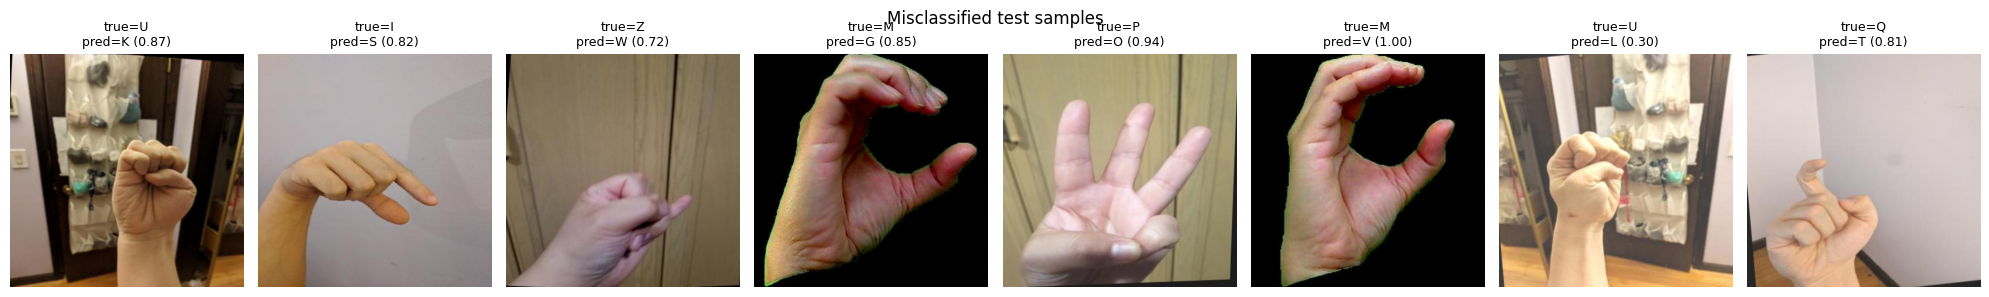

In [28]:
misclassified_idx = [i for i, (t, p) in enumerate(zip(all_true, all_preds)) if t != p]
print(f"{len(misclassified_idx)}/{len(all_true)} test samples misclassified "
      f"({100 * len(misclassified_idx) / len(all_true):.1f}%)")

n_show = min(8, len(misclassified_idx))
if n_show:
    sample_idx = random.sample(misclassified_idx, n_show)

    fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, sample_idx):
        img = cv2.cvtColor(cv2.imread(test_paths[idx]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(
            f"true={idx_to_class[all_true[idx]]}\n"
            f"pred={idx_to_class[all_preds[idx]]} ({all_conf[idx]:.2f})",
            fontsize=9,
        )
        ax.axis("off")
    plt.suptitle("Misclassified test samples")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications to display.")


## 14. Save `landmark_model.keras`

Self-contained artifact pair — inference code loads the saved Keras model
plus a small metadata JSON (class mapping, normalization, fitted scaler) and
reconstructs everything needed for prediction without retraining or
reimplementing normalization.


In [29]:
model_path = OUTPUT_DIR / "landmark_model.keras"
model.save(model_path)

checkpoint_meta = {
    "input_dim": MODEL_CONFIG["input_dim"],
    "num_classes": MODEL_CONFIG["num_classes"],
    "class_names": CLASS_NAMES,
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "normalization": NORMALIZATION_INFO,           # geometric: wrist-origin + scale-by-MCP-distance
    "scaler": {                                     # StandardScaler mean/scale, fit on X_train only
        "mean": SCALER_INFO["mean"].tolist(),
        "scale": SCALER_INFO["scale"].tolist(),
    },
    "model_config": MODEL_CONFIG,
    "best_val_accuracy": float(best_val_accuracy),
    "test_accuracy": float(test_accuracy),
}

checkpoint_meta_path = OUTPUT_DIR / "landmark_meta.json"
with open(checkpoint_meta_path, "w") as f:
    json.dump(checkpoint_meta, f, indent=2)

print(f"Saved model to {model_path}")
print(f"Saved metadata to {checkpoint_meta_path}")
print(f"  best_val_accuracy = {checkpoint_meta['best_val_accuracy']:.4f}")
print(f"  test_accuracy     = {checkpoint_meta['test_accuracy']:.4f}")


Saved model to outputs/landmark_model.keras
Saved metadata to outputs/landmark_meta.json
  best_val_accuracy = 0.9559
  test_accuracy     = 0.9289


## 15. Reload & Verification (mandatory)

Loads `landmark_model.keras` into a **fresh** model instance and confirms
predictions match the in-memory model exactly, before trusting the file for
deployment.


In [30]:
reloaded_model = keras.models.load_model(model_path)
with open(checkpoint_meta_path) as f:
    loaded_meta = json.load(f)

# Compare predictions on a handful of test samples between the in-memory
# model and the freshly reloaded one.
check_n = min(20, len(X_test))
check_idx = random.sample(range(len(X_test)), check_n)
x_check = X_test[check_idx]

pred_original = model.predict(x_check, verbose=0).argmax(axis=1)
pred_reloaded = reloaded_model.predict(x_check, verbose=0).argmax(axis=1)

matches = (pred_original == pred_reloaded).sum()
print(f"Predictions match on {matches}/{check_n} sampled test cases.")
assert matches == check_n, "Reloaded model predictions diverge from the original — investigate before deploying."
print("Reload verification passed: model loads correctly and predictions are consistent.")

# Confirm class mapping round-trips correctly (JSON keys are always strings)
assert loaded_meta["idx_to_class"]["0"] == "A"
print("Class mapping verified: index 0 -> 'A'.")


Predictions match on 20/20 sampled test cases.
Reload verification passed: model loads correctly and predictions are consistent.
Class mapping verified: index 0 -> 'A'.


## 16. Minimal Inference Functions

These are written to be dropped directly into `detector.py` / `classifier.py`
with minimal changes.


In [31]:
def load_model(model_path, meta_path):
    m = keras.models.load_model(model_path)
    with open(meta_path) as f:
        meta = json.load(f)
    return m, meta


def apply_scaler(feats: np.ndarray, scaler_info: dict) -> np.ndarray:
    """Applies the StandardScaler fit on X_train during training. Never refit at
    inference time -- mean/scale come straight from the saved metadata."""
    mean = np.array(scaler_info["mean"], dtype=np.float32)
    scale = np.array(scaler_info["scale"], dtype=np.float32)
    return ((feats - mean) / scale).astype(np.float32)


def predict_landmarks(model, meta, landmarks: np.ndarray):
    """landmarks: (21, 3) raw MediaPipe landmarks (already cropped/detected upstream).
    Pipeline: extract_features() [geometric] -> apply_scaler() [train-fit StandardScaler]
    -> model. Both steps must match training exactly -- neither is reimplemented here,
    both are pulled from the metadata / the same extract_features() used in training."""
    feats = extract_features(landmarks)
    feats = apply_scaler(feats, meta["scaler"])
    x = np.expand_dims(feats, axis=0)
    logits = model.predict(x, verbose=0)
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]
    pred_idx = int(probs.argmax())
    conf = float(probs[pred_idx])
    label = meta["idx_to_class"][str(pred_idx)]
    return {"label": label, "confidence": conf}


def predict_image(model, meta, image_bgr, hands_model, yolo_box=None):
    """image_bgr: full frame. yolo_box: optional (class_id, cx, cy, w, h) to crop first.
    Returns {'label': ..., 'confidence': ...} or {'label': None, 'confidence': 0.0} if no hand found."""
    crop = image_bgr
    if yolo_box is not None:
        cropped = crop_hand_roi(image_bgr, yolo_box)
        if cropped is not None and cropped.size > 0:
            crop = cropped

    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    landmarks = extract_landmarks_from_crop(hands_model, crop_rgb)
    if landmarks is None:
        return {"label": None, "confidence": 0.0}

    return predict_landmarks(model, meta, landmarks)


In [32]:
# --- Demo on a few real test images, end to end ---
demo_model, demo_meta = load_model(model_path, checkpoint_meta_path)

with make_hand_landmarker(running_mode=mp_vision.RunningMode.IMAGE) as demo_hands:
    demo_paths = random.sample(test_paths, min(5, len(test_paths)))
    for p in demo_paths:
        img_bgr = cv2.imread(p)
        result = predict_image(demo_model, demo_meta, img_bgr, demo_hands)
        print(f"{Path(p).name}: {result}")


D-18-_jpeg.rf.57ec7a5aebed657686c2767e9d77307f.jpg: {'label': 'T', 'confidence': 0.995025098323822}
K10_jpg.rf.ade23fb168ec14c8379d6e9f55d35ffe.jpg: {'label': 'C', 'confidence': 0.9985805749893188}
Z-52-_jpeg.rf.8f6cb3014c8524b3b34b38ad12c3d534.jpg: {'label': 'S', 'confidence': 0.9638038873672485}
K-38-_jpeg.rf.868e25cb7c04a416519221663b24c2d9.jpg: {'label': 'C', 'confidence': 0.9999819993972778}
T15_jpg.rf.6d8abff8cfed075cb7b165a315b6022c.jpg: {'label': 'L', 'confidence': 0.8626663088798523}


## Next Steps

- Copy `outputs/landmark_model.keras` and `outputs/landmark_meta.json` into
  the `sign2voice/model/` location per the project structure, and adjust
  `classifier.py` to load a Keras SavedModel + JSON metadata pair instead of
  a pickled scikit-learn model.
- Move `extract_features()` and `NORMALIZATION_INFO` into `features.py`
  verbatim — no reimplementation, to guarantee train/inference parity.
- Move `build_landmark_mlp()`, `load_model()`, `predict_landmarks()` into `classifier.py`.
- `detector.py` should own the live MediaPipe `HandLandmarker` instance --
  build it with `make_hand_landmarker(running_mode=mp_vision.RunningMode.VIDEO)`
  (or `LIVE_STREAM` with a callback, for async webcam use) rather than `IMAGE`
  mode, and hand off raw landmarks to `classifier.py`. Ship `hand_landmarker.task`
  alongside the app rather than re-downloading it at runtime.
- Review `landmark_extraction_failures.csv` — if any single letter has a
  disproportionate failure rate, that's worth calling out explicitly in the
  graduation report's limitations section rather than glossing over it.
- If test accuracy on visually-similar letters (M/N/S/T, U/V, etc. — check
  the confused-pairs list above) is weak, that's expected for a static-only
  MVP and is legitimate discussion material for "future work: temporal
  modeling to disambiguate motion-dependent letters."
